In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re


In [2]:
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import Dense


In [3]:
df = pd.read_csv(r"C:\Users\tanay\Downloads\IMDB Dataset (1).csv",
    encoding="latin-1",
    engine="python",
    on_bad_lines="skip"
)

print("Dataset Loaded Successfully")
print(df.head())


Dataset Loaded Successfully
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [4]:
df = df.dropna()

In [5]:
# =========================================
def clean_text(text):

    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z ]', '', text)

    return text


df['review'] = df['review'].apply(clean_text)


In [6]:
# =========================================
# 5. CONVERT LABELS
# positive -> 1
# negative -> 0
# =========================================
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

print(df['sentiment'].value_counts())



sentiment
0    24778
1    24770
Name: count, dtype: int64


In [7]:
# =========================================
# 6. TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [8]:
# =========================================
# 7. TOKENIZATION
# Convert words into sequences
# =========================================
tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)


In [9]:
# =========================================
# 8. PADDING
# Make all reviews same length
# =========================================
X_train = pad_sequences(X_train, maxlen=200)
X_test = pad_sequences(X_test, maxlen=200)

In [10]:
model = Sequential([

    # Embedding Layer
    Embedding(10000, 32),

    # Pooling Layer
    GlobalAveragePooling1D(),

    # Hidden Layer
    Dense(32, activation='relu'),

    # Output Layer
    Dense(1, activation='sigmoid')
])

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)



Epoch 1/5
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8115 - loss: 0.4123 - val_accuracy: 0.8690 - val_loss: 0.3022
Epoch 2/5
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.8919 - loss: 0.2633 - val_accuracy: 0.8794 - val_loss: 0.2829
Epoch 3/5
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9084 - loss: 0.2284 - val_accuracy: 0.8600 - val_loss: 0.3270
Epoch 4/5
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9170 - loss: 0.2092 - val_accuracy: 0.8728 - val_loss: 0.3047
Epoch 5/5
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - accuracy: 0.9249 - loss: 0.1941 - val_accuracy: 0.8757 - val_loss: 0.3127


In [14]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8757 - loss: 0.3127

Test Accuracy: 0.8756811022758484


In [15]:
predictions = model.predict(X_test[:5])

print("\nPredictions:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step

Predictions:
[[0.0069906 ]
 [0.9999822 ]
 [0.00424021]
 [0.03849363]
 [0.01672193]]


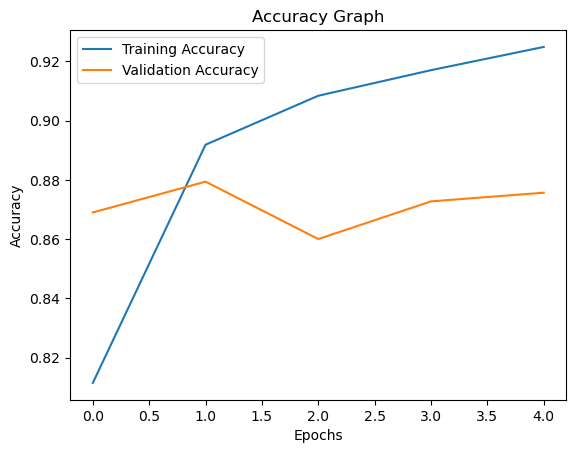

In [16]:
plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()